In [ ]:
# ─── Path resolution ───────────────────────────────────────────────────
# This notebook lives in toptag/studies/, but it reads the .scaled files
# from, and writes its plot directory into, the analysis working directory
# two levels up. Run this cell FIRST so every relative path below resolves
# against that root, exactly as in plot_fjpt_toptagTEST.py.
# Guarded so re-running the cell is a no-op rather than climbing further.
import os
if os.path.basename(os.getcwd()) == "studies":
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
print("cwd:", os.getcwd())


In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mplhep as hep
import lz4.frame
import cloudpickle

hep.style.use("CMS")


# AK15 Leading Jet $p_T$ — Data/MC Comparison (hadmonotop2022_toptagTEST2)

Data/MC stack + ratio plots of the AK15 leading jet $p_T$ (`fjpt`) distribution
from `hadmonotop2022_toptagTEST2.scaled`, split by the top-tag working point
(`TvsQCD` fail/pass, WP = 0.33), one plot per region.

**Why `fjpt` and not `fjpt_cat`:** `fjpt_cat` additionally carries `n_qinfj`/
`n_binfj` (truth-level quark/b-flavor matching used to classify jets into the
8-class scheme in `toptag/README.md`) and is bkg-only — it exists to derive
top-tag efficiencies and scale factors, not for a data/MC comparison (data
has no truth quark/b-flavor info). `fjpt` (`region`, `fjpt`, `TvsQCD` axes
only) is the one with real `MET`/`EGamma` data, so it's the right histogram
for this plot. `fjpt_cat` and its classification plots
(`plot_fjpt_class_toptagTEST.py`, `plots_2022_toptagTEST*_class*/`) are left
untouched.

**This is written as a normal data/MC comparison plot** (background stack +
uncertainty band + data points + Data/MC ratio panel), the same layout as
`plot_stack.py` / `plot_stack_toptag.py`. `get_bkg_arrays` only draws
processes actually present in the file, and `get_data_arrays` returns `None`
gracefully if a region/dataset isn't filled, so this keeps working unchanged
as more backgrounds (`QCD Multijet`, `G + Jets` are still missing) are added.

**Note on scale:** as of 2026-09-21 (`hadmonotop2022_toptagTEST2.scaled`),
`bkg` now has the full background set: `WW`, `WZ`, `ZZ`, `QCD Multijet`, `TT`,
`ST`, `Z ($\nu\nu$) + Jets`, `Z ($\ell\ell$) + Jets`, `W ($\ell\nu$) + Jets`,
`G + Jets` (the two previously-missing processes, `QCD Multijet` and
`G + Jets`, are now present); `data` has real `MET`/`EGamma` entries. This is
still a small private MC test sample, so its absolute yields are likely far
below the real full data yields — don't read the Data/MC ratio panel as a
physics result yet, it's expected to be off-scale until the MC is normalized
to the full dataset.


## Load data

In [2]:
INPUT_FILE = "hadmonotop2022_toptagTEST2.scaled"
LUMI = 7.99  # 2022preEE, fb^-1

with open(INPUT_FILE, "rb") as f:
    raw = cloudpickle.loads(lz4.frame.decompress(f.read()))

bkg_data = raw["bkg"]
dat_data = raw["data"]

# fjpt (region, fjpt, TvsQCD) is the data/MC comparison histogram.
# fjpt_cat is bkg-only (used for top-tag SF derivation) and is not used here.
VAR = "fjpt"
VAR_LABEL = r"AK15 jet $p_{\mathrm{T}}$ [GeV]"

print("bkg processes for fjpt:", list(bkg_data[VAR].keys()))
print("data datasets for fjpt:", list(dat_data[VAR].keys()))


bkg processes for fjpt: ['WW', 'WZ', 'ZZ', 'QCD Multijet', 'TT', 'ST', 'Z ($\\nu\\nu$) + Jets', 'Z ($\\ell\\ell$) + Jets', 'W ($\\ell\\nu$) + Jets', 'G + Jets']
data datasets for fjpt: ['MET', 'EGamma']


/var/folders/rw/47krd_5n6vjdzz2ndqj4_g7c0000gn/T/ipykernel_88769/2408745484.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  raw = cloudpickle.loads(lz4.frame.decompress(f.read()))


## Configuration

In [3]:
OUTDIR_BASE = "plots_2022_toptagTEST2_0921_fjpt"

REGION_DATASET = {
    "sr":   "MET",
    "wmcr": "MET",
    "tmcr": "MET",
    "zmcr": "MET",
    "wecr": "EGamma",
    "tecr": "EGamma",
    "gcr":  "EGamma",
    "zecr": "EGamma",
}

REGION_LABEL = {
    "sr":   "SR",
    "wmcr": "W(mu) CR",
    "tmcr": r"$t\bar{t}$(mu) CR",
    "zmcr": "Z(mumu) CR",
    "wecr": "W(e) CR",
    "tecr": r"$t\bar{t}$(e) CR",
    "gcr":  "gamma CR",
    "zecr": "Z(ee) CR",
}

# Per-region stack order (bottom -> top); VV = WW+WZ+ZZ combined.
# Only processes actually present in the input file are drawn (see
# get_bkg_arrays), so this list is safe to keep even as more backgrounds
# (QCD Multijet, G+Jets) are added to the input file later.
BKG_ORDER = {
    "sr":   [r"Z ($\nu\nu$) + Jets", r"W ($\ell\nu$) + Jets", "VV", "TT", r"G + Jets", "ST", r"Z ($\ell\ell$) + Jets", "QCD Multijet"][::-1],
    "wmcr": [r"W ($\ell\nu$) + Jets", "TT", "QCD Multijet", "VV", "ST", r"Z ($\ell\ell$) + Jets", r"Z ($\nu\nu$) + Jets", r"G + Jets"][::-1],
    "tmcr": [r"W ($\ell\nu$) + Jets", "TT", "QCD Multijet", "VV", "ST", r"Z ($\ell\ell$) + Jets", r"Z ($\nu\nu$) + Jets", r"G + Jets"][::-1],
    "wecr": [r"W ($\ell\nu$) + Jets", "TT", "QCD Multijet", "VV", "ST", r"Z ($\ell\ell$) + Jets", r"Z ($\nu\nu$) + Jets", r"G + Jets"][::-1],
    "tecr": [r"W ($\ell\nu$) + Jets", "TT", "QCD Multijet", "VV", "ST", r"Z ($\ell\ell$) + Jets", r"Z ($\nu\nu$) + Jets", r"G + Jets"][::-1],
    "zecr": [r"Z ($\ell\ell$) + Jets", r"W ($\ell\nu$) + Jets", "TT", "QCD Multijet", "VV", "ST", r"Z ($\nu\nu$) + Jets", r"G + Jets"][::-1],
    "zmcr": [r"Z ($\ell\ell$) + Jets", r"W ($\ell\nu$) + Jets", "TT", "QCD Multijet", "VV", "ST", r"Z ($\nu\nu$) + Jets", r"G + Jets"][::-1],
    "gcr":  [r"G + Jets", r"W ($\ell\nu$) + Jets", "TT", "QCD Multijet", "VV", "ST", r"Z ($\ell\ell$) + Jets", r"Z ($\nu\nu$) + Jets"][::-1],
}

# WW, WZ, ZZ are merged into VV
VV_PROCS = ["WW", "WZ", "ZZ"]

BKG_COLOR = {
    "QCD Multijet":            "#2ca02c",
    r"Z ($\ell\ell$) + Jets":  "#aec7e8",
    r"Z ($\nu\nu$) + Jets":    "#ffbb78",
    r"G + Jets":               "#98df8a",
    r"W ($\ell\nu$) + Jets":   "#1f77b4",
    "ST":                      "#e377c2",
    "TT":                      "#ff7f0e",
    "VV":                      "#9467bd",
}

BKG_LEGEND = {
    "QCD Multijet":            "QCD Multijet",
    r"Z ($\ell\ell$) + Jets":  r"Z($\ell\ell$)+jets",
    r"Z ($\nu\nu$) + Jets":    r"Z($\nu\nu$)+jets",
    r"G + Jets":               r"$\gamma$+jets",
    r"W ($\ell\nu$) + Jets":   r"W($\ell\nu$)+jets",
    "ST":                      "Single top",
    "TT":                      r"$t\bar{t}$",
    "VV":                      "Diboson",
}

# TvsQCD axis edges are [0, 0.33, 1] -> bin 0 = fail, bin 1 = pass (WP = 0.33)
TAG_CATEGORIES = {
    "toptag_fail": 0,
    "toptag_pass": 1,
}

TAG_LABEL = {
    "toptag_fail": "fail",
    "toptag_pass": "pass",
}


## Selection helpers

In [4]:
def slice_region_cat(h, region, cat_idx):
    """Select region, and the TvsQCD-cut bin if this histogram has that axis."""
    sel = {"region": region}
    if "TvsQCD" in h.axes.name:
        sel["TvsQCD"] = cat_idx
    return h[sel]


def get_bkg_arrays(region, cat_idx):
    """Return list of (label, values, edges) per stack entry; VV is WW+WZ+ZZ summed.

    Only processes actually present in bkg_data[VAR] are included, so this
    works unchanged as more backgrounds are added to the input file.
    """
    result = []
    for proc in BKG_ORDER[region]:
        if proc == "VV":
            vv_vals, vv_edges = None, None
            for vv in VV_PROCS:
                if vv not in bkg_data.get(VAR, {}):
                    continue
                h = bkg_data[VAR][vv]
                if region not in list(h.axes["region"]):
                    continue
                hs = slice_region_cat(h, region, cat_idx)
                v = np.where(np.isfinite(hs.values()), hs.values(), 0)
                e = np.array(list(hs.axes[0].edges))
                vv_vals = v if vv_vals is None else vv_vals + v
                vv_edges = e
            if vv_vals is not None:
                result.append(("VV", vv_vals, vv_edges))
        else:
            if proc not in bkg_data.get(VAR, {}):
                continue
            h = bkg_data[VAR][proc]
            if region not in list(h.axes["region"]):
                continue
            hs = slice_region_cat(h, region, cat_idx)
            vals = np.where(np.isfinite(hs.values()), hs.values(), 0)
            edges = np.array(list(hs.axes[0].edges))
            result.append((proc, vals, edges))
    return result


def get_data_arrays(region, cat_idx):
    """Return (values, bin centers, errors) for the data histogram, or (None, None, None)."""
    dataset = REGION_DATASET[region]
    if dataset not in dat_data.get(VAR, {}):
        return None, None, None
    h = dat_data[VAR][dataset]
    if region not in list(h.axes["region"]):
        return None, None, None
    hs = slice_region_cat(h, region, cat_idx)
    vals = hs.values()
    edges = np.array(list(hs.axes[0].edges))
    centers = 0.5 * (edges[:-1] + edges[1:])
    return vals, centers, np.sqrt(vals)


## Plotting function

In [5]:
def make_stack_plot(region, cat_name, cat_idx, outdir, outname, save=True):
    """Data/MC stack + ratio plot of fjpt for one region and one toptag category."""
    bkg_list = get_bkg_arrays(region, cat_idx)
    dat_vals, dat_centers, dat_errs = get_data_arrays(region, cat_idx)

    if not bkg_list:
        print(f"  Skipping {region} [{cat_name}]: no bkg data")
        return None, None

    total_sum = sum(np.sum(v) for _, v, _ in bkg_list)
    data_sum = np.sum(dat_vals) if dat_vals is not None else 0
    if total_sum == 0 and data_sum == 0:
        print(f"  Skipping {region} [{cat_name}]: empty")
        return None, None

    edges = bkg_list[0][2]
    bkg_vals_list = [v for _, v, _ in bkg_list]
    bkg_cumsum = np.cumsum(bkg_vals_list, axis=0)
    total_bkg = bkg_cumsum[-1]

    # --- Figure layout -------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(
        2, 1, figsize=(8, 8),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
        sharex=True,
    )

    # --- Main panel: stepfilled stack -----------------------------------------
    prev = np.zeros(len(total_bkg))
    for (proc, vals, _), top in zip(bkg_list, bkg_cumsum):
        ax_main.stairs(
            top, edges,
            baseline=prev,
            fill=True,
            color=BKG_COLOR.get(proc, "gray"),
            edgecolor="black",
            linewidth=1.5,
            label=BKG_LEGEND.get(proc, proc),
        )
        prev = top.copy()

    # total bkg uncertainty band
    bkg_err = np.sqrt(total_bkg)
    ax_main.stairs(
        total_bkg + bkg_err, edges,
        baseline=total_bkg - bkg_err,
        fill=True,
        color="none", edgecolor="gray", hatch="///",
        label="Bkg unc.", linewidth=0,
    )

    # data points
    if dat_vals is not None:
        ax_main.errorbar(
            dat_centers, dat_vals, yerr=dat_errs,
            fmt="o", color="black", markersize=4,
            linewidth=1, capsize=2, label="Data",
            zorder=5,
        )

    ax_main.set_yscale("log")

    # Decade-rounded ylim + decade-only major ticks: avoids matplotlib's
    # "6 x 10^0"-style multiplier tick labels on narrow-range log axes, which
    # widen the left margin and push the CMS header text into the lumi label.
    combined = total_bkg + bkg_err
    if dat_vals is not None:
        combined = np.concatenate([combined, dat_vals])
    nonzero = combined[combined > 0]
    ylo = 10 ** np.floor(np.log10(nonzero.min())) if len(nonzero) else 1e-2
    yhi = 10 ** np.ceil(np.log10(nonzero.max()) + 1) if len(nonzero) else 1e2
    ax_main.set_ylim(ylo, yhi)
    ax_main.yaxis.set_major_locator(mticker.LogLocator(base=10.0))
    ax_main.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax_main.yaxis.set_minor_formatter(mticker.NullFormatter())

    ax_main.set_ylabel("Events / bin")
    ax_main.set_xlim(edges[0], edges[-1])

    # Legend: Data first, bkg reversed (top of stack -> bottom), Bkg unc. last
    handles, labels = ax_main.get_legend_handles_labels()
    order = []
    for i, lbl in enumerate(labels):
        if lbl == "Data":
            order.insert(0, i)
        elif lbl == "Bkg unc.":
            order.append(i)
        else:
            order.insert(1 if order and labels[order[0]] == "Data" else 0, i)

    leg = ax_main.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title=f"{REGION_LABEL[region]}, {TAG_LABEL[cat_name]}",
        title_fontsize=10,
        ncol=2, fontsize=9, framealpha=0.8,
        loc="upper right",
    )
    leg.get_title().set_ha("center")
    leg.get_title().set_fontweight("bold")

    hep.cms.label(
        "Private Work", data=True,
        lumi=LUMI, com=13.6,
        ax=ax_main,
    )

    # --- Ratio panel -----------------------------------------------------------
    if dat_vals is not None:
        ratio     = np.where(total_bkg > 0, dat_vals / total_bkg, np.nan)
        ratio_err = np.where(total_bkg > 0, dat_errs / total_bkg, np.nan)
        bkg_rel   = np.where(total_bkg > 0, bkg_err / total_bkg, 0)
        bin_w     = edges[1:] - edges[:-1]

        ax_ratio.bar(
            edges[:-1], 2 * bkg_rel, width=bin_w,
            bottom=1 - bkg_rel, align="edge",
            color="gray", alpha=0.4,
        )
        ax_ratio.errorbar(
            dat_centers, ratio, yerr=ratio_err,
            fmt="o", color="black", markersize=4,
            linewidth=1, capsize=2, zorder=5,
        )
        ax_ratio.axhline(1, color="gray", linestyle="--", linewidth=1)

    ax_ratio.set_xlabel(VAR_LABEL)
    ax_ratio.set_ylabel("Data / MC")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_yticks([0.6, 0.8, 1.0, 1.2, 1.4])

    if save:
        base = os.path.join(outdir, outname)
        fig.savefig(f"{base}.pdf", bbox_inches="tight")
        fig.savefig(f"{base}.png", dpi=300, bbox_inches="tight")
        print(f"  Saved: {base}.pdf / .png")

    return fig, (ax_main, ax_ratio)


## Plots per toptag category per region

One subdirectory per toptag category (fail/pass) under `OUTDIR_BASE`, one
stack+ratio plot per region inside it -- 2 x 8 = 16 plots, saved to disk and
closed rather than displayed inline (see the example below for a quick
visual check).


In [6]:
for cat_name, cat_idx in TAG_CATEGORIES.items():
    outdir = os.path.join(OUTDIR_BASE, cat_name)
    os.makedirs(outdir, exist_ok=True)
    for region in REGION_DATASET:
        print(f"Plotting {VAR} in {region} [{cat_name}] ...")
        fig, _ = make_stack_plot(region, cat_name, cat_idx, outdir, f"stack_{region}_{VAR}")
        if fig is not None:
            plt.close(fig)
    print(f"Done with {cat_name}. Plots saved in {outdir}/")


Plotting fjpt in sr [toptag_fail] ...


  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_fail/stack_sr_fjpt.pdf / .png
Plotting fjpt in wmcr [toptag_fail] ...


  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_fail/stack_wmcr_fjpt.pdf / .png
Plotting fjpt in tmcr [toptag_fail] ...


  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_fail/stack_tmcr_fjpt.pdf / .png
Plotting fjpt in zmcr [toptag_fail] ...


  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_fail/stack_zmcr_fjpt.pdf / .png
Plotting fjpt in wecr [toptag_fail] ...


...

  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_pass/stack_zmcr_fjpt.pdf / .png
Plotting fjpt in wecr [toptag_pass] ...


  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_pass/stack_wecr_fjpt.pdf / .png
Plotting fjpt in tecr [toptag_pass] ...


  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_pass/stack_tecr_fjpt.pdf / .png
Plotting fjpt in gcr [toptag_pass] ...


  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_pass/stack_gcr_fjpt.pdf / .png
Plotting fjpt in zecr [toptag_pass] ...


  Saved: plots_2022_toptagTEST2_0921_fjpt/toptag_pass/stack_zecr_fjpt.pdf / .png
Done with toptag_pass. Plots saved in plots_2022_toptagTEST2_0921_fjpt/toptag_pass/


## Example: one category/region inline

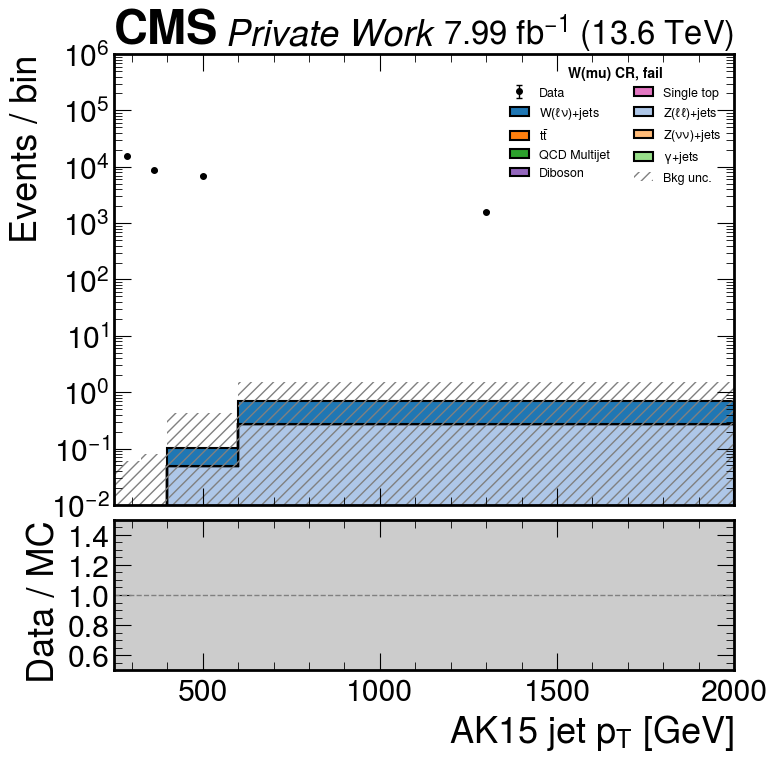

In [7]:
fig, _ = make_stack_plot("wmcr", "toptag_fail", 0, OUTDIR_BASE, "example", save=False)
plt.show()
